# TELCO CUSTOMER CHURN PREDICTION USING ANN

This project aims to predict customer churn in a telecommunications company using a simple Artificial Neural Network (ANN). We will cover data loading, preprocessing, model building, training, evaluation, and finally, make predictions for individual customers.

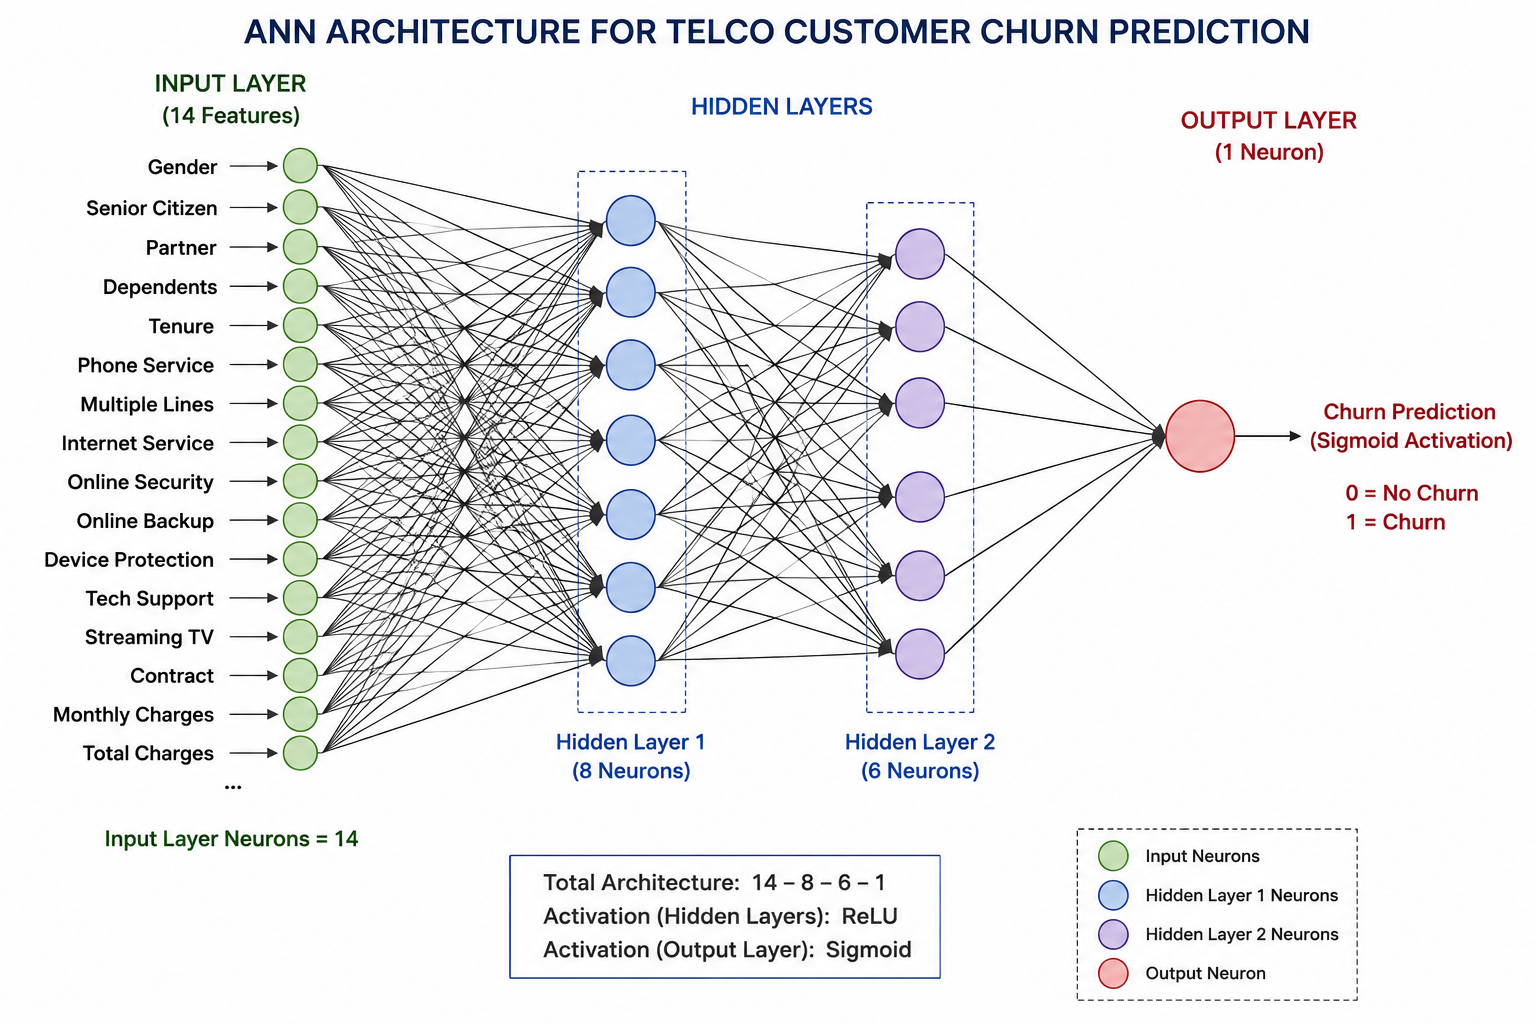


## 1. IMPORT LIBRARIES

We start by importing all the necessary Python libraries for data manipulation, numerical operations, plotting, machine learning preprocessing, and building our Deep Learning model.

In [ ]:
# Import data manipulation and numerical libraries
import pandas as pd
import numpy as np

# Import plotting library
import matplotlib.pyplot as plt
import seaborn as sns # Often used for better looking plots

# Import scikit-learn for data splitting, scaling, and evaluation metrics
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Import TensorFlow and Keras for building the ANN model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

## 2. UPLOAD TELCO CSV

We will use `files.upload()` to directly upload the dataset from your local machine to Google Colab. After uploading, we'll load it into a pandas DataFrame.

In [ ]:
# Import files module from google.colab to handle file uploads
from google.colab import files

# Upload the file from your local system
uploaded = files.upload()

# Get the name of the uploaded file
filename = list(uploaded.keys())[0]

# Read the CSV file into a pandas DataFrame
df = pd.read_excel(filename)

print("\nDataset loaded successfully!")
print("Dataset Shape:", df.shape)

# Display the first few rows of the DataFrame
print("\nFirst 5 rows of the dataset:")
display(df.head())

Saving Telco_Customer_Churn_Excel.xlsx to Telco_Customer_Churn_Excel (1).xlsx

Dataset loaded successfully!
Dataset Shape: (7043, 21)

First 5 rows of the dataset:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 3. UNDERSTAND DATA

It's important to understand the dataset's structure, data types, and check for any missing values or statistical summaries before proceeding with preprocessing.

In [ ]:
# Print concise summary of the DataFrame including data types and non-null values
print("\nDataFrame Info:")
print(df.info())

# Print the count of missing values for each column
print("\nMissing values per column:")
print(df.isnull().sum())

# Print descriptive statistics for numerical columns
print("\nDescriptive Statistics:")
print(df.describe())


DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 no

## 4. DATA PREPROCESSING

This crucial step prepares our raw data for the ANN model. It involves handling missing values, converting data types, removing irrelevant columns, and encoding categorical features.

In [ ]:
# Convert 'TotalCharges' to numeric, coercing errors to NaN
# The 'TotalCharges' column is currently an object type because of some non-numeric entries (e.g., empty strings).
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# Handle missing values in 'TotalCharges' by filling with the median
# Filling with median is a common strategy to avoid distortion caused by outliers.
df["TotalCharges"] = df["TotalCharges"].fillna(df["TotalCharges"].median())
print(f"Missing values in 'TotalCharges' after handling: {df['TotalCharges'].isnull().sum()}")

# Remove 'customerID' column as it is a unique identifier and not useful for prediction
df.drop("customerID", axis=1, inplace=True)
print("\n'customerID' column removed.")

# Convert 'Churn' column from categorical ('Yes', 'No') to numerical (1, 0)
# This is our target variable for binary classification.
df["Churn"] = df["Churn"].map({"No": 0, "Yes": 1})
print("\n'Churn' column converted to numerical (0=No Churn, 1=Churn).")

# Convert all remaining categorical columns into numerical using One-Hot Encoding
# `pd.get_dummies` creates new columns for each category and drops the original ones.
# `drop_first=True` avoids multicollinearity by dropping the first category in each feature.
df = pd.get_dummies(df, drop_first=True)
print("\nCategorical columns have been One-Hot Encoded.")

print("\nDataFrame after Preprocessing (first 5 rows):")
display(df.head())
print("\nDataFrame Info after Preprocessing:")
df.info()

Missing values in 'TotalCharges' after handling: 0

'customerID' column removed.

'Churn' column converted to numerical (0=No Churn, 1=Churn).

Categorical columns have been One-Hot Encoded.

DataFrame after Preprocessing (first 5 rows):


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,False,True,False,False,True,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,0,True,False,False,True,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,1,True,False,False,True,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,0,True,False,False,False,True,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,1,False,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False



DataFrame Info after Preprocessing:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 31 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   SeniorCitizen                          7043 non-null   int64  
 1   tenure                                 7043 non-null   int64  
 2   MonthlyCharges                         7043 non-null   float64
 3   TotalCharges                           7043 non-null   float64
 4   Churn                                  7043 non-null   int64  
 5   gender_Male                            7043 non-null   bool   
 6   Partner_Yes                            7043 non-null   bool   
 7   Dependents_Yes                         7043 non-null   bool   
 8   PhoneService_Yes                       7043 non-null   bool   
 9   MultipleLines_No phone service         7043 non-null   bool   
 10  MultipleLines_Yes                  

## 5. EXPLORATORY DATA ANALYSIS (EDA)

Before proceeding with model training, let's perform some Exploratory Data Analysis to understand our data better. This helps in identifying patterns, relationships, and potential insights.

/tmp/ipykernel_2751/1722610559.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Churn', data=df, palette='viridis')


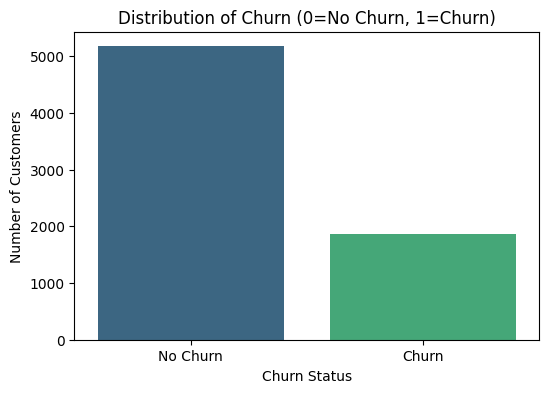

In [ ]:
# 1. Distribution of the Target Variable (Churn)
# Visualize the distribution of 'Churn' to check for class imbalance.
plt.figure(figsize=(6, 4))
sns.countplot(x='Churn', data=df, palette='viridis')
plt.title('Distribution of Churn (0=No Churn, 1=Churn)')
plt.xlabel('Churn Status')
plt.ylabel('Number of Customers')
plt.xticks(ticks=[0, 1], labels=['No Churn', 'Churn'])
plt.show()

The churn distribution shows that 'No Churn' customers are significantly more numerous than 'Churn' customers, indicating a class imbalance. This is a common issue in churn prediction datasets and should be considered during model evaluation.

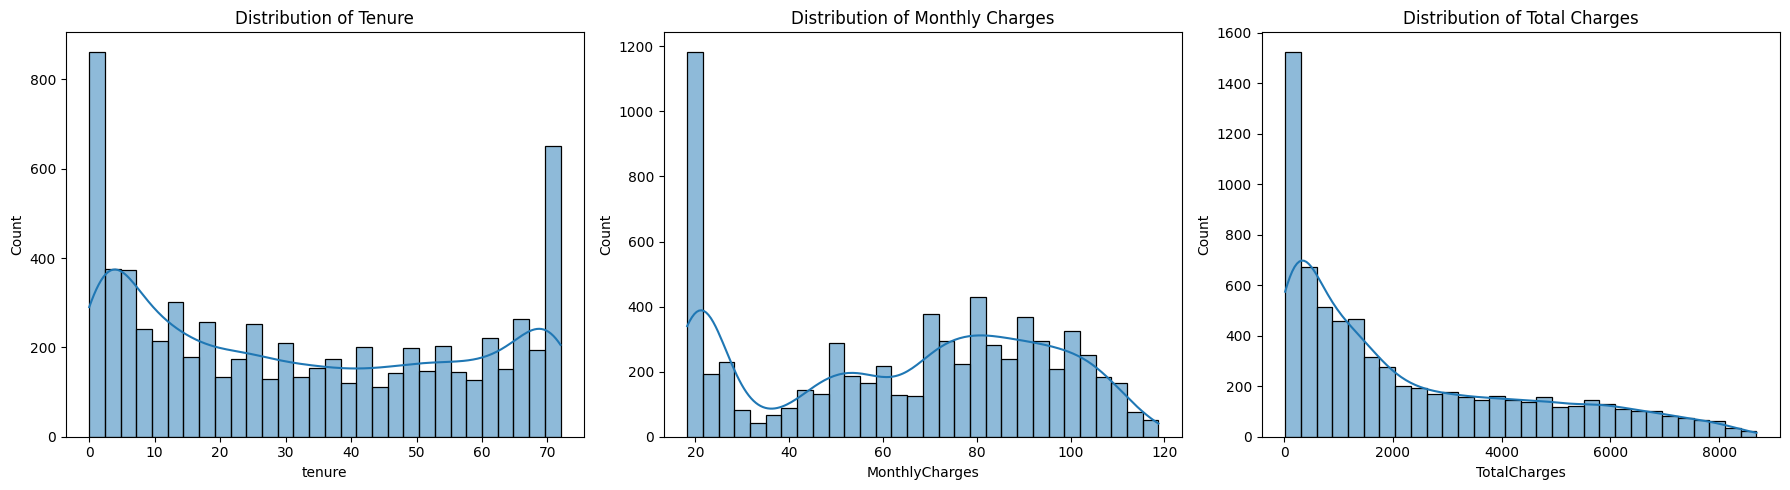

In [ ]:
# 2. Distribution of Numerical Features
# Examine 'tenure', 'MonthlyCharges', and 'TotalCharges'

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(df['tenure'], bins=30, kde=True, ax=axes[0])
axes[0].set_title('Distribution of Tenure')

sns.histplot(df['MonthlyCharges'], bins=30, kde=True, ax=axes[1])
axes[1].set_title('Distribution of Monthly Charges')

sns.histplot(df['TotalCharges'], bins=30, kde=True, ax=axes[2])
axes[2].set_title('Distribution of Total Charges')

plt.tight_layout()
plt.show()

From the numerical feature distributions:
- **Tenure**: Shows a bimodal distribution, with a high number of new customers (low tenure) and long-term customers (high tenure).
- **MonthlyCharges**: Has a relatively even distribution, with peaks around lower and higher charges, suggesting different service packages.
- **TotalCharges**: Skewed towards lower values, which is expected given the higher number of new customers. This feature might be highly correlated with tenure.

### 5. Distributions of Other Key Categorical Features

For binary and categorical features, a `countplot` is more suitable to visualize the number of occurrences for each category, rather than a `histplot` which is typically used for continuous numerical data.

/tmp/ipykernel_2751/218561579.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='SeniorCitizen', data=df.astype({'SeniorCitizen': 'int'}), palette='viridis')


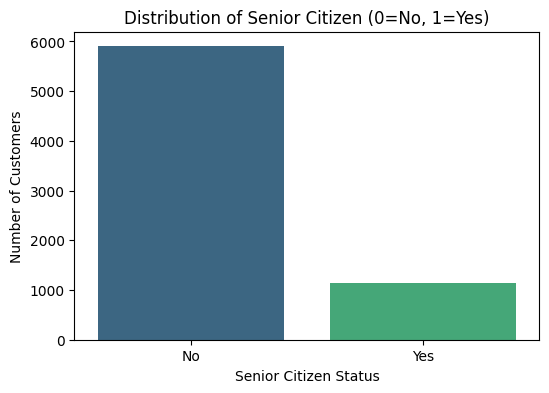

In [ ]:
# 5. Distribution of SeniorCitizen (Binary Categorical)
plt.figure(figsize=(6, 4))
sns.countplot(x='SeniorCitizen', data=df.astype({'SeniorCitizen': 'int'}), palette='viridis')
plt.title('Distribution of Senior Citizen (0=No, 1=Yes)')
plt.xlabel('Senior Citizen Status')
plt.ylabel('Number of Customers')
plt.xticks(ticks=[0, 1], labels=['No', 'Yes'])
plt.show()

/tmp/ipykernel_2751/1314416945.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='gender_Male', data=df.astype({'gender_Male': 'int'}), palette='viridis')


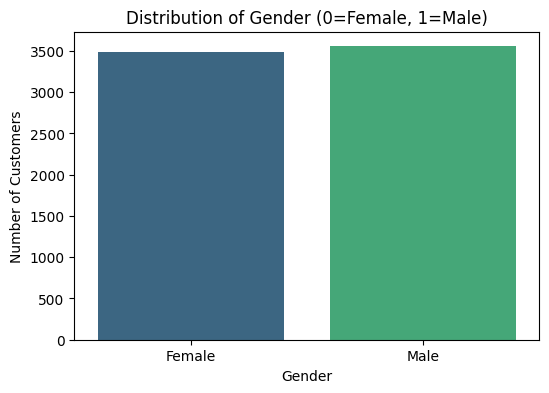

In [ ]:
# 6. Distribution of Gender
plt.figure(figsize=(6, 4))
sns.countplot(x='gender_Male', data=df.astype({'gender_Male': 'int'}), palette='viridis')
plt.title('Distribution of Gender (0=Female, 1=Male)')
plt.xlabel('Gender')
plt.ylabel('Number of Customers')
plt.xticks(ticks=[0, 1], labels=['Female', 'Male'])
plt.show()

/tmp/ipykernel_2751/3415419800.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='InternetService_Fiber optic', data=df.astype({'InternetService_Fiber optic': 'int'}), palette='viridis')


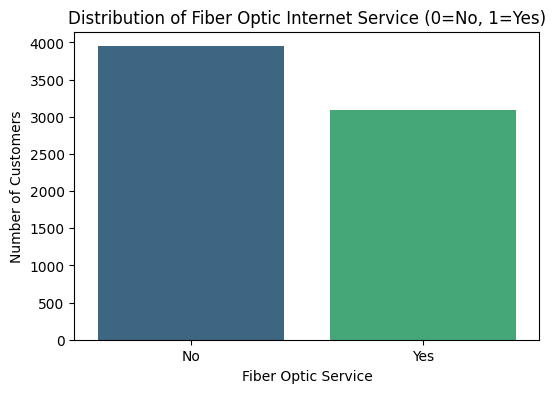

In [ ]:
# 7. Distribution of Internet Service Type (Fiber Optic)
plt.figure(figsize=(6, 4))
sns.countplot(x='InternetService_Fiber optic', data=df.astype({'InternetService_Fiber optic': 'int'}), palette='viridis')
plt.title('Distribution of Fiber Optic Internet Service (0=No, 1=Yes)')
plt.xlabel('Fiber Optic Service')
plt.ylabel('Number of Customers')
plt.xticks(ticks=[0, 1], labels=['No', 'Yes'])
plt.show()

/tmp/ipykernel_2751/3854428209.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Contract_Two year', data=df.astype({'Contract_Two year': 'int'}), palette='viridis')


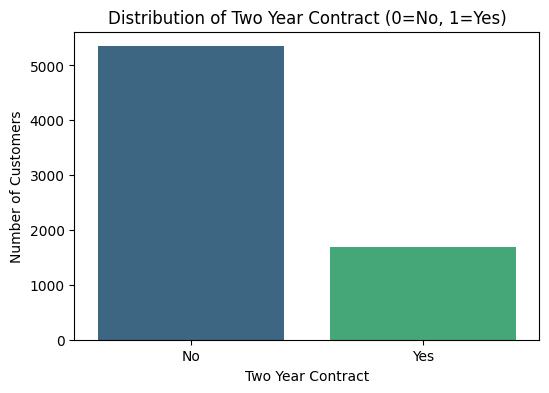

In [ ]:
# 8. Distribution of Contract Type (Two Year)
plt.figure(figsize=(6, 4))
sns.countplot(x='Contract_Two year', data=df.astype({'Contract_Two year': 'int'}), palette='viridis')
plt.title('Distribution of Two Year Contract (0=No, 1=Yes)')
plt.xlabel('Two Year Contract')
plt.ylabel('Number of Customers')
plt.xticks(ticks=[0, 1], labels=['No', 'Yes'])
plt.show()

/tmp/ipykernel_2751/3162131247.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='PaymentMethod_Electronic check', data=df.astype({'PaymentMethod_Electronic check': 'int'}), palette='viridis')


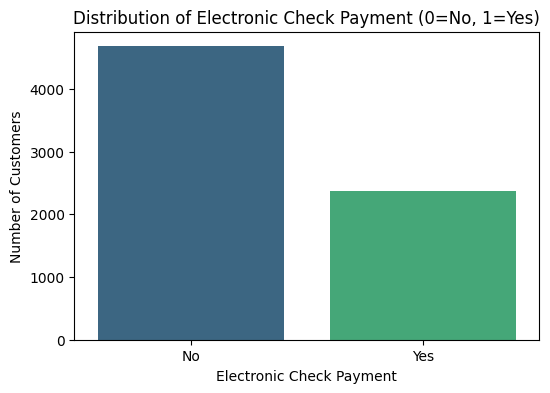

In [ ]:
# 9. Distribution of Payment Method (Electronic Check)
plt.figure(figsize=(6, 4))
sns.countplot(x='PaymentMethod_Electronic check', data=df.astype({'PaymentMethod_Electronic check': 'int'}), palette='viridis')
plt.title('Distribution of Electronic Check Payment (0=No, 1=Yes)')
plt.xlabel('Electronic Check Payment')
plt.ylabel('Number of Customers')
plt.xticks(ticks=[0, 1], labels=['No', 'Yes'])
plt.show()

/tmp/ipykernel_2751/4014001865.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Partner_Yes', data=df.astype({'Partner_Yes': 'int'}), palette='viridis')


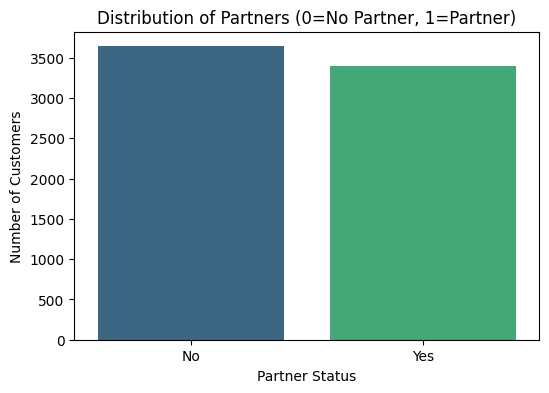

In [ ]:
# 10. Distribution of Partner Status
plt.figure(figsize=(6, 4))
sns.countplot(x='Partner_Yes', data=df.astype({'Partner_Yes': 'int'}), palette='viridis')
plt.title('Distribution of Partners (0=No Partner, 1=Partner)')
plt.xlabel('Partner Status')
plt.ylabel('Number of Customers')
plt.xticks(ticks=[0, 1], labels=['No', 'Yes'])
plt.show()

/tmp/ipykernel_2751/1340580345.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Dependents_Yes', data=df.astype({'Dependents_Yes': 'int'}), palette='viridis')


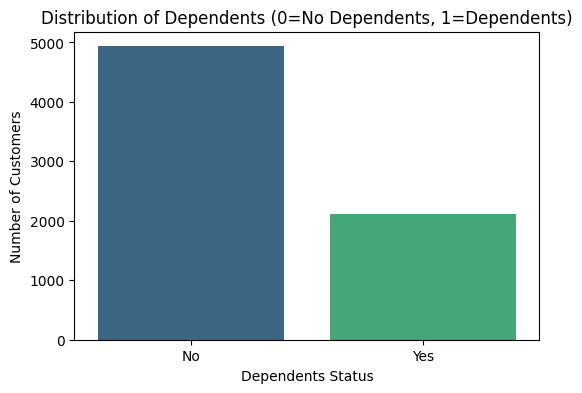

In [ ]:
# 11. Distribution of Dependents Status
plt.figure(figsize=(6, 4))
sns.countplot(x='Dependents_Yes', data=df.astype({'Dependents_Yes': 'int'}), palette='viridis')
plt.title('Distribution of Dependents (0=No Dependents, 1=Dependents)')
plt.xlabel('Dependents Status')
plt.ylabel('Number of Customers')
plt.xticks(ticks=[0, 1], labels=['No', 'Yes'])
plt.show()

/tmp/ipykernel_2751/422751999.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='PaperlessBilling_Yes', data=df.astype({'PaperlessBilling_Yes': 'int'}), palette='viridis')


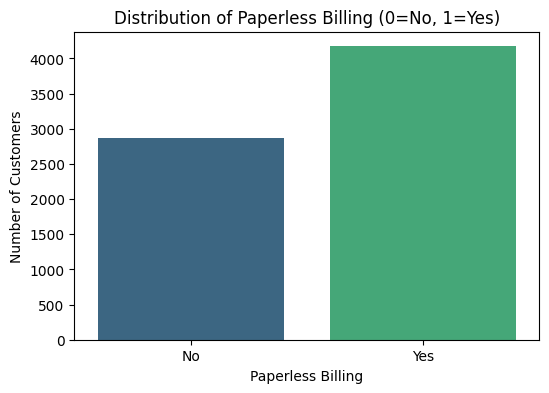

In [ ]:
# 12. Distribution of Paperless Billing
plt.figure(figsize=(6, 4))
sns.countplot(x='PaperlessBilling_Yes', data=df.astype({'PaperlessBilling_Yes': 'int'}), palette='viridis')
plt.title('Distribution of Paperless Billing (0=No, 1=Yes)')
plt.xlabel('Paperless Billing')
plt.ylabel('Number of Customers')
plt.xticks(ticks=[0, 1], labels=['No', 'Yes'])
plt.show()

After reviewing these distributions, it's clear that many of the one-hot encoded binary features show varying proportions between their 'Yes' and 'No' categories, which is valuable for understanding customer demographics and service uptake.

We have now covered the distributions for key numerical features and a representative set of binary/categorical features. This completes a thorough initial Exploratory Data Analysis.

## 5.2 Outlier Detection

Identifying outliers is crucial as they can significantly impact model training. We will use box plots to visualize outliers and the Interquartile Range (IQR) method to statistically identify them in our numerical features.

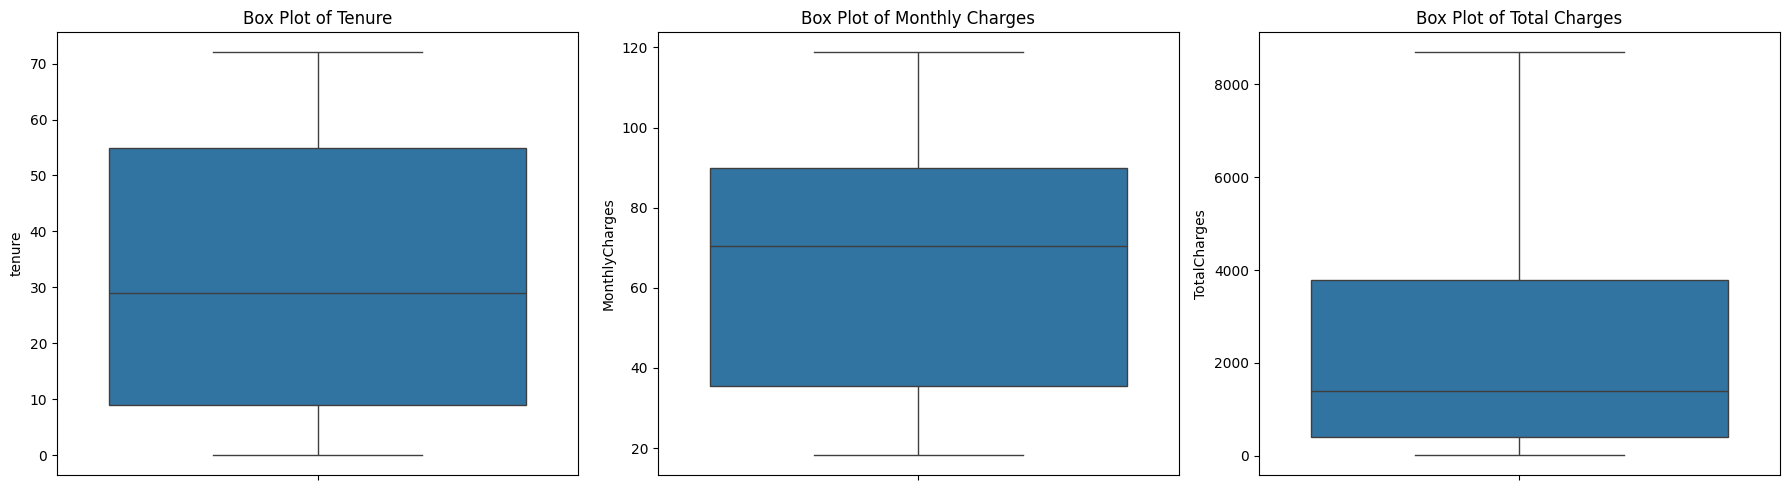

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Box plots for numerical features to visualize outliers
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.boxplot(y=df['tenure'], ax=axes[0])
axes[0].set_title('Box Plot of Tenure')

sns.boxplot(y=df['MonthlyCharges'], ax=axes[1])
axes[1].set_title('Box Plot of Monthly Charges')

sns.boxplot(y=df['TotalCharges'], ax=axes[2])
axes[2].set_title('Box Plot of Total Charges')

plt.tight_layout()
plt.show()

From the box plots, we can visually identify potential outliers. Now, let's use the IQR method to quantify these outliers for each numerical column.

In [ ]:
# Function to detect outliers using IQR
def find_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return outliers

# Find and display outliers for 'tenure'
outliers_tenure = find_outliers_iqr(df, 'tenure')
print(f"\nNumber of outliers in Tenure: {len(outliers_tenure)}")
if not outliers_tenure.empty:
    print("Outliers in Tenure (first 5 rows):")
    display(outliers_tenure[['tenure', 'MonthlyCharges', 'TotalCharges']].head())
else:
    print("No outliers found in Tenure using IQR method.")


# Find and display outliers for 'MonthlyCharges'
outliers_monthly_charges = find_outliers_iqr(df, 'MonthlyCharges')
print(f"\nNumber of outliers in MonthlyCharges: {len(outliers_monthly_charges)}")
if not outliers_monthly_charges.empty:
    print("Outliers in MonthlyCharges (first 5 rows):")
    display(outliers_monthly_charges[['tenure', 'MonthlyCharges', 'TotalCharges']].head())
else:
    print("No outliers found in MonthlyCharges using IQR method.")


# Find and display outliers for 'TotalCharges'
outliers_total_charges = find_outliers_iqr(df, 'TotalCharges')
print(f"\nNumber of outliers in TotalCharges: {len(outliers_total_charges)}")
if not outliers_total_charges.empty:
    print("Outliers in TotalCharges (first 5 rows):")
    display(outliers_total_charges[['tenure', 'MonthlyCharges', 'TotalCharges']].head())
else:
    print("No outliers found in TotalCharges using IQR method.")


Number of outliers in Tenure: 0
No outliers found in Tenure using IQR method.

Number of outliers in MonthlyCharges: 0
No outliers found in MonthlyCharges using IQR method.

Number of outliers in TotalCharges: 0
No outliers found in TotalCharges using IQR method.


## 5.3 Correlation Analysis

Understanding the correlation between features and the target variable (`Churn`) can provide valuable insights into which factors are most influential in predicting churn. We will visualize these correlations using a heatmap.

Correlation with Churn (sorted):
Churn                                    1.000000
InternetService_Fiber optic              0.308020
PaymentMethod_Electronic check           0.301919
MonthlyCharges                           0.193356
PaperlessBilling_Yes                     0.191825
SeniorCitizen                            0.150889
StreamingTV_Yes                          0.063228
StreamingMovies_Yes                      0.061382
MultipleLines_Yes                        0.040102
PhoneService_Yes                         0.011942
gender_Male                             -0.008612
MultipleLines_No phone service          -0.011942
DeviceProtection_Yes                    -0.066160
OnlineBackup_Yes                        -0.082255
PaymentMethod_Mailed check              -0.091683
PaymentMethod_Credit card (automatic)   -0.134302
Partner_Yes                             -0.150448
Dependents_Yes                          -0.164221
TechSupport_Yes                         -0.164674
OnlineSecurity_Ye

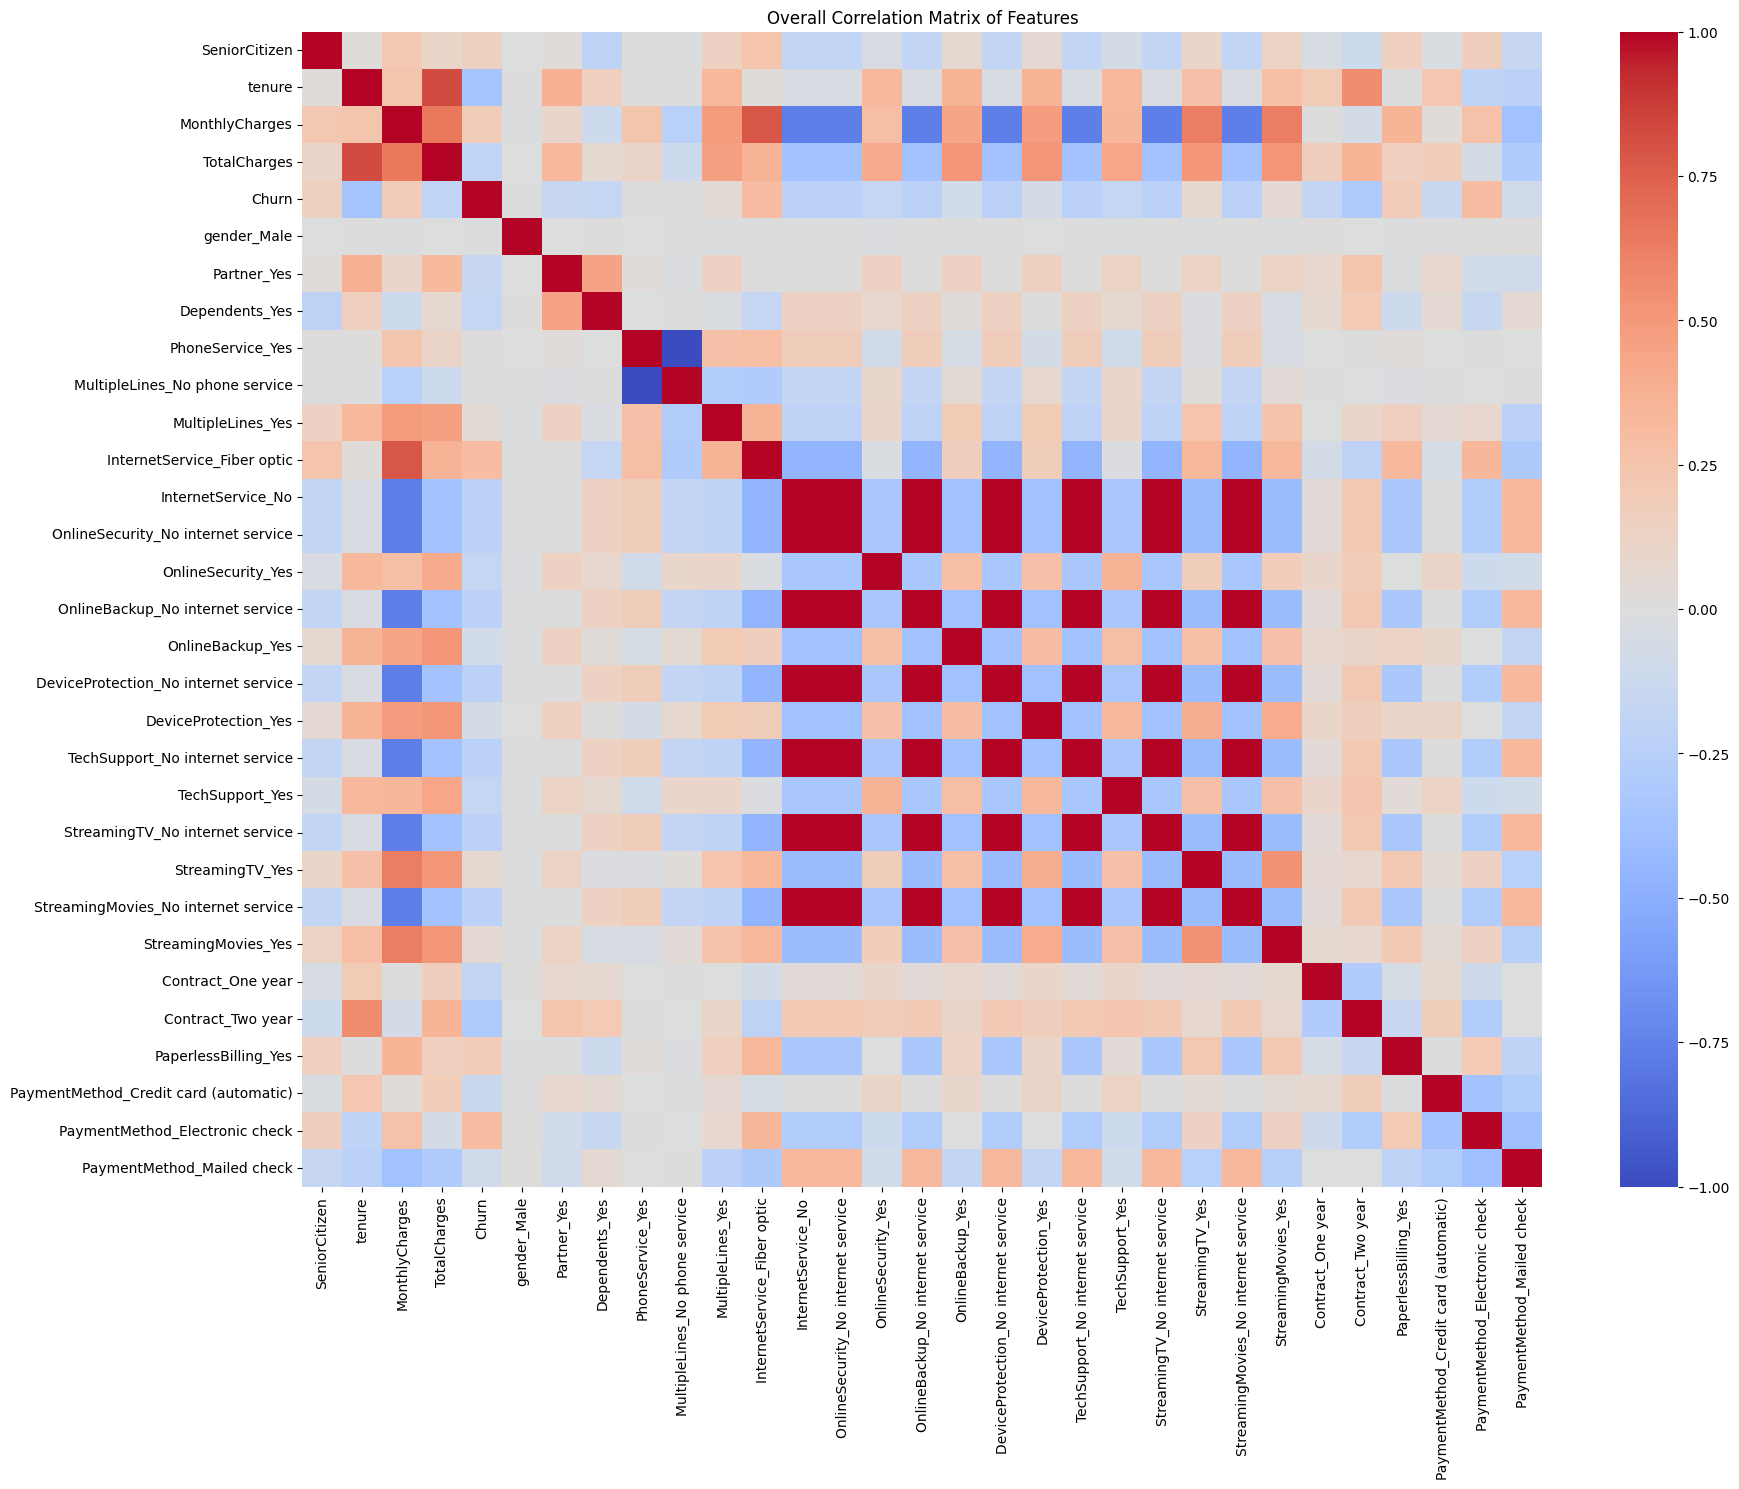

/tmp/ipykernel_2751/4031413889.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=churn_correlations.index, y=churn_correlations.values, palette='viridis')


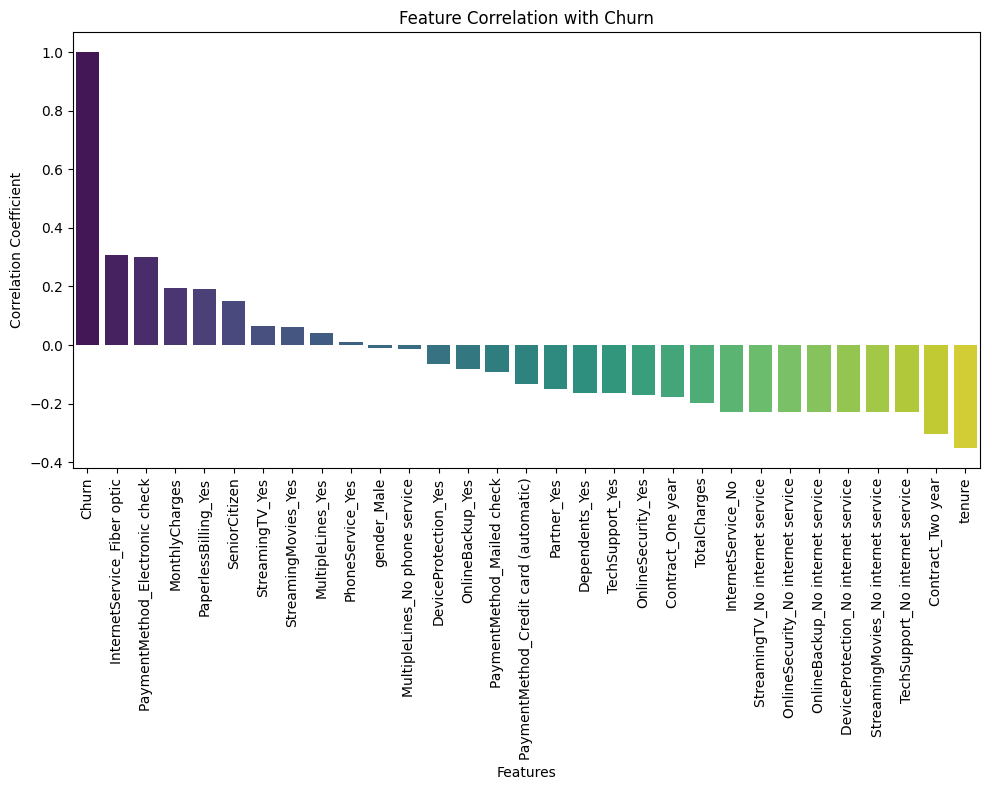

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the correlation matrix
correlation_matrix = df.corr()

# Filter for correlations with the 'Churn' column
churn_correlations = correlation_matrix['Churn'].sort_values(ascending=False)

print("Correlation with Churn (sorted):")
print(churn_correlations)

# Visualize the correlation matrix (optional, for overall feature relationships)
plt.figure(figsize=(20, 15))
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', fmt=".2f")
plt.title('Overall Correlation Matrix of Features')
plt.show()

# Visualize only the correlation with Churn (more focused)
plt.figure(figsize=(10, 8))
sns.barplot(x=churn_correlations.index, y=churn_correlations.values, palette='viridis')
plt.xticks(rotation=90)
plt.title('Feature Correlation with Churn')
plt.ylabel('Correlation Coefficient')
plt.xlabel('Features')
plt.tight_layout()
plt.show()

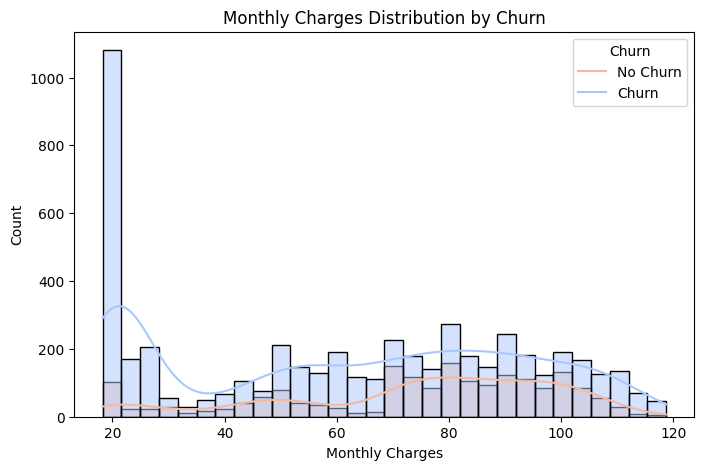

In [ ]:
# 3. Churn by MonthlyCharges
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='MonthlyCharges', hue='Churn', kde=True, palette='coolwarm', bins=30)
plt.title('Monthly Charges Distribution by Churn')
plt.xlabel('Monthly Charges')
plt.ylabel('Count')
plt.legend(title='Churn', labels=['No Churn', 'Churn'])
plt.show()

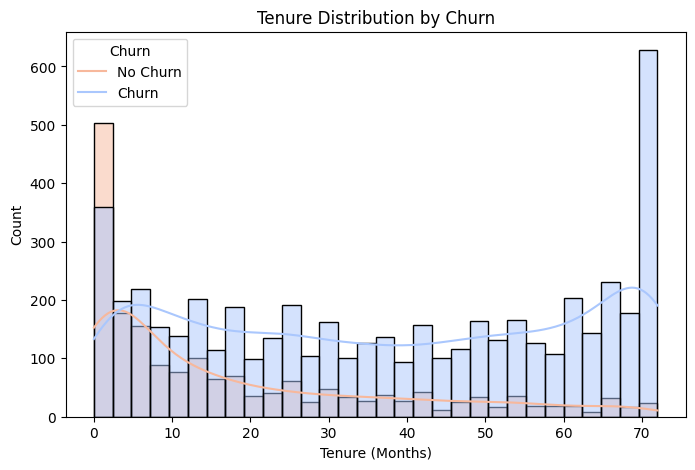

In [ ]:
# 4. Churn by Tenure
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='tenure', hue='Churn', kde=True, palette='coolwarm', bins=30)
plt.title('Tenure Distribution by Churn')
plt.xlabel('Tenure (Months)')
plt.ylabel('Count')
plt.legend(title='Churn', labels=['No Churn', 'Churn'])
plt.show()

These plots suggest:
- **MonthlyCharges**: Customers with higher monthly charges appear to have a higher propensity to churn.
- **Tenure**: New customers (low tenure) show a higher churn rate compared to long-term customers.

## 6. SEPARATE FEATURES AND TARGET

We split the preprocessed DataFrame into features (X), which are the input to our model, and the target variable (y), which our model will predict.

In [ ]:
# Features (X) are all columns except 'Churn'
X = df.drop("Churn", axis=1)

# Target (y) is the 'Churn' column
y = df["Churn"]

# Print the shapes of the feature and target sets
print("Input (Features) Shape:", X.shape)
print("Target (Churn) Shape:", y.shape)

Input (Features) Shape: (7043, 30)
Target (Churn) Shape: (7043,)


## 7. TRAIN TEST SPLIT

We divide our data into training and testing sets. The training set is used to train the model, and the testing set is used to evaluate its performance on unseen data. We use an 80/20 split and `stratify=y` to ensure an even distribution of churn cases in both sets.

In [ ]:
# Split the data into 80% training and 20% testing sets
# `random_state` ensures reproducibility of the split.
# `stratify=y` ensures that the proportion of target classes (churn/no churn) is the same in both train and test sets.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Data split successfully:")
print(f"Training set has {len(X_train)} samples (80%)")
print(f"Testing set has {len(X_test)} samples (20%)")

Data split successfully:
Training set has 5634 samples (80%)
Testing set has 1409 samples (20%)


## 8. FEATURE SCALING

Feature scaling is important for ANNs to ensure that all features contribute equally to the model's training and to help the optimization algorithm converge faster. We use `StandardScaler` to transform our features.

In [ ]:
# Initialize the StandardScaler
scaler = StandardScaler()

# Fit the scaler on the training data and transform X_train
# This learns the mean and standard deviation from the training data.
X_train = scaler.fit_transform(X_train)

# Transform X_test using the same scaler fitted on X_train
# It's crucial to use the same scaling parameters from the training set.
X_test = scaler.transform(X_test)

print("Features scaled successfully!")
print("X_train_scaled (first 5 rows):\n", X_train[:5])
print("\nX_test_scaled (first 5 rows):\n", X_test[:5])

Features scaled successfully!
X_train_scaled (first 5 rows):
 [[-0.44177295  0.10237124 -0.52197565 -0.26328906  0.99433624 -0.96923413
  -0.65155653 -3.01309011  3.01309011 -0.85833837 -0.88769579 -0.52408075
  -0.52408075 -0.63611103 -0.52408075 -0.73554636 -0.52408075  1.37557156
  -0.52408075 -0.64327425 -0.52408075  1.25216312 -0.52408075  1.24796703
  -0.51278214 -0.56382155 -1.20265302 -0.52380561  1.40690298 -0.54384572]
 [-0.44177295 -0.71174346  0.33747781 -0.50481448  0.99433624  1.03174245
   1.53478624  0.3318852  -0.3318852  -0.85833837  1.12651205 -0.52408075
  -0.52408075  1.57205259 -0.52408075 -0.73554636 -0.52408075 -0.72697054
  -0.52408075 -0.64327425 -0.52408075 -0.79861799 -0.52408075 -0.80130322
  -0.51278214 -0.56382155 -1.20265302 -0.52380561 -0.71078107  1.83875676]
 [-0.44177295 -0.79315493 -0.80901319 -0.75121344  0.99433624  1.03174245
   1.53478624 -3.01309011  3.01309011 -0.85833837 -0.88769579 -0.52408075
  -0.52408075  1.57205259 -0.52408075  1.3595336

## 8. CREATE SIMPLE ANN

We will now build a simple Artificial Neural Network using Keras's Sequential API. The architecture will consist of an input layer, three dense hidden layers with ReLU activation, and an output layer with a single neuron and Sigmoid activation for binary classification.

In [ ]:
# Create a Sequential model
model = Sequential([

    # First hidden layer with 64 neurons and ReLU activation
    # input_shape specifies the number of features in our input data.
    Dense(
        64,
        activation="relu",
        input_shape=(X_train.shape[1],)
    ),

    # Second hidden layer with 32 neurons and ReLU activation
    Dense(
        32,
        activation="relu"
    ),

    # Third hidden layer with 16 neurons and ReLU activation
    Dense(
        16,
        activation="relu"
    ),

    # Output layer with 1 neuron and Sigmoid activation
    # Sigmoid activation outputs a probability between 0 and 1, suitable for binary classification.
    Dense(
        1,
        activation="sigmoid"
    )
])

# Display the model's architecture summary
print("ANN Model Summary:")
model.summary()

ANN Model Summary:


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_48 (Dense)                │ (None, 64)             │         1,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_49 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_50 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_51 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,609 (18.00 KB)

 Trainable params: 4,609 (18.00 KB)

 Non-trainable params: 0 (0.00 B)

## 9. COMPILE ANN

Compiling the model involves configuring its learning process. We specify the optimizer, loss function, and metrics to monitor during training.

In [ ]:
# Compile the model
# 'adam' optimizer is an efficient choice for many deep learning tasks.
# 'binary_crossentropy' is the standard loss function for binary classification.
# 'accuracy' is the metric we want to observe during training and evaluation.
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully!")

Model compiled successfully!


## 10. TRAIN ANN

We will now train our ANN model using the `fit` method. The training process involves feeding the model with training data for a specified number of epochs, in mini-batches, and monitoring its performance on a validation set.

In [ ]:
batch_sizes = [32, 64, 128] # Original batch size plus the requested new ones

for batch_size in batch_sizes:
    print(f"\nTraining with batch size: {batch_size}")
    # Train the model
    # `epochs` specifies how many times the entire dataset is passed through the network.
    # `batch_size` is the number of samples processed before the model is updated.
    # `validation_split` reserves 20% of the training data for validation during training.
    # `verbose=1` displays a progress bar during training.
    history = model.fit(
        X_train,
        y_train,
        epochs=50,
        batch_size=batch_size,
        validation_split=0.20,
        verbose=1
    )

    print(f"\nModel training complete for batch size {batch_size}!")


Training with batch size: 32
Epoch 1/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7704 - loss: 0.4639 - val_accuracy: 0.7773 - val_loss: 0.4457
Epoch 2/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8034 - loss: 0.4174 - val_accuracy: 0.7773 - val_loss: 0.4452
Epoch 3/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8074 - loss: 0.4074 - val_accuracy: 0.7791 - val_loss: 0.4438
Epoch 4/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8130 - loss: 0.4015 - val_accuracy: 0.7888 - val_loss: 0.4411
Epoch 5/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8152 - loss: 0.3963 - val_accuracy: 0.7862 - val_loss: 0.4424
Epoch 6/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8192 - loss: 0.3909 - val_accuracy: 0.7826 - val_loss: 0.4440
Epoch 7/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8209 - loss: 0.3855 - val_accuracy: 0.7870 - val_loss: 0.4479
Epoch 8/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8223 - l

In [ ]:
histories = {}

for batch_size in batch_sizes:
    print(f"\nRetraining with batch size: {batch_size}")
    # Re-create the model to ensure a fresh start for each batch size
    # This is important because `model.fit` continues training from where it left off
    # if the model object is reused without re-compilation or re-initialization.
    model_new = Sequential([
        Dense(64, activation="relu", input_shape=(X_train.shape[1],)),
        Dense(32, activation="relu"),
        Dense(16, activation="relu"),
        Dense(1, activation="sigmoid")
    ])
    model_new.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

    history = model_new.fit(
        X_train,
        y_train,
        epochs=50,
        batch_size=batch_size,
        validation_split=0.20,
        verbose=0 # Suppress verbose output during re-training
    )

    # Evaluate the current model on the test data
    test_loss_current, test_accuracy_current = model_new.evaluate(X_test, y_test, verbose=0)

    histories[batch_size] = {
        'history': history,
        'test_loss': test_loss_current,
        'test_accuracy': test_accuracy_current
    }
    print(f"Model re-training complete for batch size {batch_size}!")


Retraining with batch size: 32
Model re-training complete for batch size 32!

Retraining with batch size: 64
Model re-training complete for batch size 64!

Retraining with batch size: 128
Model re-training complete for batch size 128!


In [ ]:
print("\n--- Test Metrics by Batch Size ---")
for batch_size, metrics in histories.items():
    print(f"\nBatch Size: {batch_size}")
    print(f"  Test Accuracy: {metrics['test_accuracy'] * 100:.2f}%")
    print(f"  Test Loss: {metrics['test_loss']:.4f}")


--- Test Metrics by Batch Size ---

Batch Size: 32
  Test Accuracy: 74.31%
  Test Loss: 0.7516

Batch Size: 64
  Test Accuracy: 76.30%
  Test Loss: 0.6372

Batch Size: 128
  Test Accuracy: 77.00%
  Test Loss: 0.5525


In [ ]:
print("\n--- Training Metrics by Batch Size (Last Epoch) ---")
for batch_size, metrics in histories.items():
    train_history = metrics['history']
    last_epoch_accuracy = train_history.history['accuracy'][-1]
    last_epoch_loss = train_history.history['loss'][-1]
    print(f"\nBatch Size: {batch_size}")
    print(f"  Training Accuracy (last epoch): {last_epoch_accuracy * 100:.2f}%")
    print(f"  Training Loss (last epoch): {last_epoch_loss:.4f}")


--- Training Metrics by Batch Size (Last Epoch) ---

Batch Size: 32
  Training Accuracy (last epoch): 91.95%
  Training Loss (last epoch): 0.1884

Batch Size: 64
  Training Accuracy (last epoch): 90.50%
  Training Loss (last epoch): 0.2260

Batch Size: 128
  Training Accuracy (last epoch): 88.13%
  Training Loss (last epoch): 0.2689


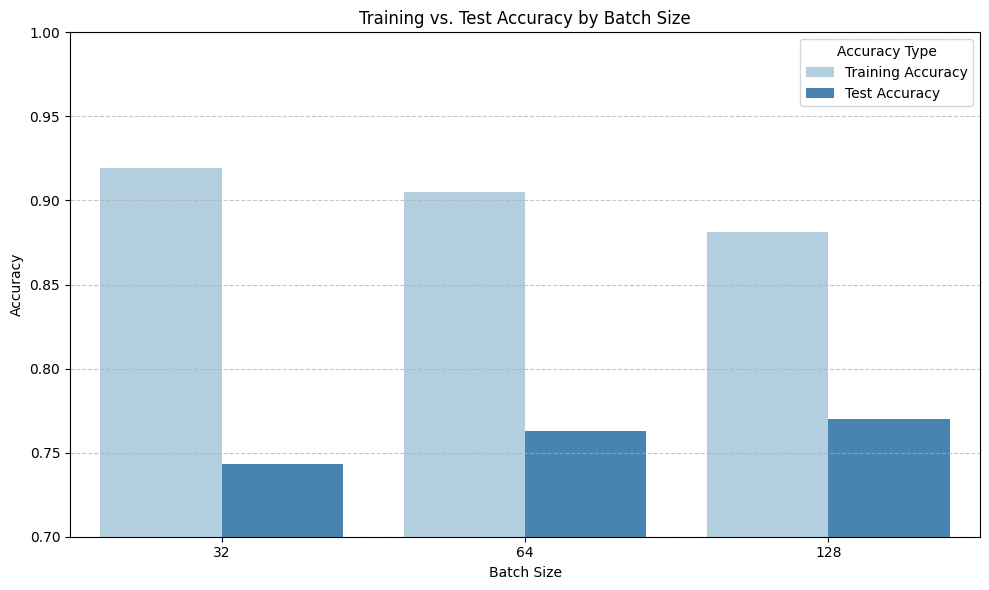

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Prepare data for plotting accuracy
accuracy_data_batch_size = []
for batch_size, metrics_data in histories.items():
    train_acc = metrics_data['history'].history['accuracy'][-1]
    test_acc = metrics_data['test_accuracy']
    accuracy_data_batch_size.append({'Batch Size': batch_size, 'Metric': 'Training Accuracy', 'Value': train_acc})
    accuracy_data_batch_size.append({'Batch Size': batch_size, 'Metric': 'Test Accuracy', 'Value': test_acc})

df_accuracy_batch_size = pd.DataFrame(accuracy_data_batch_size)

# Create the grouped bar chart for accuracy
plt.figure(figsize=(10, 6))
sns.barplot(x='Batch Size', y='Value', hue='Metric', data=df_accuracy_batch_size, palette='Blues')
plt.title('Training vs. Test Accuracy by Batch Size')
plt.xlabel('Batch Size')
plt.ylabel('Accuracy')
plt.ylim(0.7, 1.0) # Adjust y-limit for better visualization
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Accuracy Type')
plt.tight_layout()
plt.show()

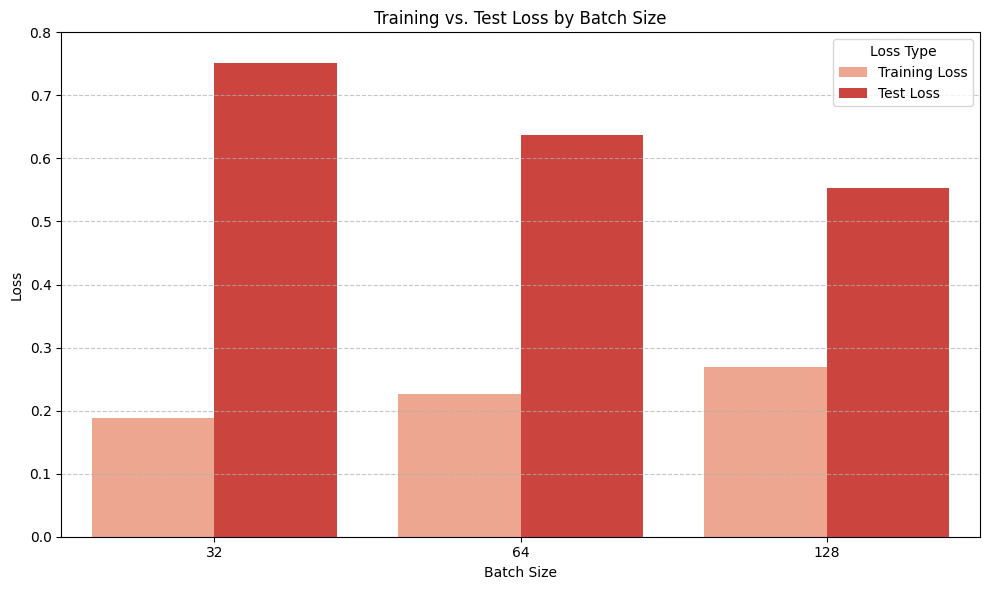

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Prepare data for plotting loss
loss_data_batch_size = []
for batch_size, metrics_data in histories.items():
    train_loss = metrics_data['history'].history['loss'][-1]
    test_loss = metrics_data['test_loss']
    loss_data_batch_size.append({'Batch Size': batch_size, 'Metric': 'Training Loss', 'Value': train_loss})
    loss_data_batch_size.append({'Batch Size': batch_size, 'Metric': 'Test Loss', 'Value': test_loss})

df_loss_batch_size = pd.DataFrame(loss_data_batch_size)

# Create the grouped bar chart for loss
plt.figure(figsize=(10, 6))
sns.barplot(x='Batch Size', y='Value', hue='Metric', data=df_loss_batch_size, palette='Reds')
plt.title('Training vs. Test Loss by Batch Size')
plt.xlabel('Batch Size')
plt.ylabel('Loss')
plt.ylim(0.0, 0.8) # Adjust y-limit for better visualization
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Loss Type')
plt.tight_layout()
plt.show()

In [ ]:
epoch_sizes = [10, 20, 30, 40, 50]
fixed_batch_size = 32
epoch_histories = {}

print("\n--- Training Models with Fixed Batch Size (32) and Varying Epochs ---")
for epochs_val in epoch_sizes:
    print(f"\nTraining with batch size: {fixed_batch_size} and epochs: {epochs_val}")
    # Re-create the model to ensure a fresh start for each run
    model_epoch_run = Sequential([
        Dense(64, activation="relu", input_shape=(X_train.shape[1],)),
        Dense(32, activation="relu"),
        Dense(16, activation="relu"),
        Dense(1, activation="sigmoid")
    ])
    model_epoch_run.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

    history = model_epoch_run.fit(
        X_train,
        y_train,
        epochs=epochs_val,
        batch_size=fixed_batch_size,
        validation_split=0.20,
        verbose=0 # Suppress verbose output during re-training
    )

    # Evaluate the current model on the test data
    test_loss_current, test_accuracy_current = model_epoch_run.evaluate(X_test, y_test, verbose=0)

    epoch_histories[epochs_val] = {
        'history': history,
        'test_loss': test_loss_current,
        'test_accuracy': test_accuracy_current
    }
    print(f"Model training complete for epochs {epochs_val}!")


--- Training Models with Fixed Batch Size (32) and Varying Epochs ---

Training with batch size: 32 and epochs: 10


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model training complete for epochs 10!

Training with batch size: 32 and epochs: 20
Model training complete for epochs 20!

Training with batch size: 32 and epochs: 30
Model training complete for epochs 30!

Training with batch size: 32 and epochs: 40
Model training complete for epochs 40!

Training with batch size: 32 and epochs: 50
Model training complete for epochs 50!


In [ ]:
print("\n--- Training and Test Metrics by Epoch Size (Batch Size = 32) ---")
for epochs_val, metrics_data in epoch_histories.items():
    train_history = metrics_data['history']
    last_epoch_train_accuracy = train_history.history['accuracy'][-1]
    last_epoch_train_loss = train_history.history['loss'][-1]
    test_accuracy = metrics_data['test_accuracy']
    test_loss = metrics_data['test_loss']

    print(f"\nEpochs: {epochs_val}")
    print(f"  Training Accuracy (last epoch): {last_epoch_train_accuracy * 100:.2f}%")
    print(f"  Test Accuracy: {test_accuracy * 100:.2f}%")
    print(f"  Training Loss (last epoch): {last_epoch_train_loss:.4f}")
    print(f"  Test Loss: {test_loss:.4f}")


--- Training and Test Metrics by Epoch Size (Batch Size = 32) ---

Epochs: 10
  Training Accuracy (last epoch): 82.63%
  Test Accuracy: 78.57%
  Training Loss (last epoch): 0.3747
  Test Loss: 0.4348

Epochs: 20
  Training Accuracy (last epoch): 85.56%
  Test Accuracy: 77.71%
  Training Loss (last epoch): 0.3263
  Test Loss: 0.4625

Epochs: 30
  Training Accuracy (last epoch): 89.02%
  Test Accuracy: 76.22%
  Training Loss (last epoch): 0.2573
  Test Loss: 0.5817

Epochs: 40
  Training Accuracy (last epoch): 89.62%
  Test Accuracy: 76.65%
  Training Loss (last epoch): 0.2429
  Test Loss: 0.5696

Epochs: 50
  Training Accuracy (last epoch): 91.52%
  Test Accuracy: 76.22%
  Training Loss (last epoch): 0.1953
  Test Loss: 0.7278


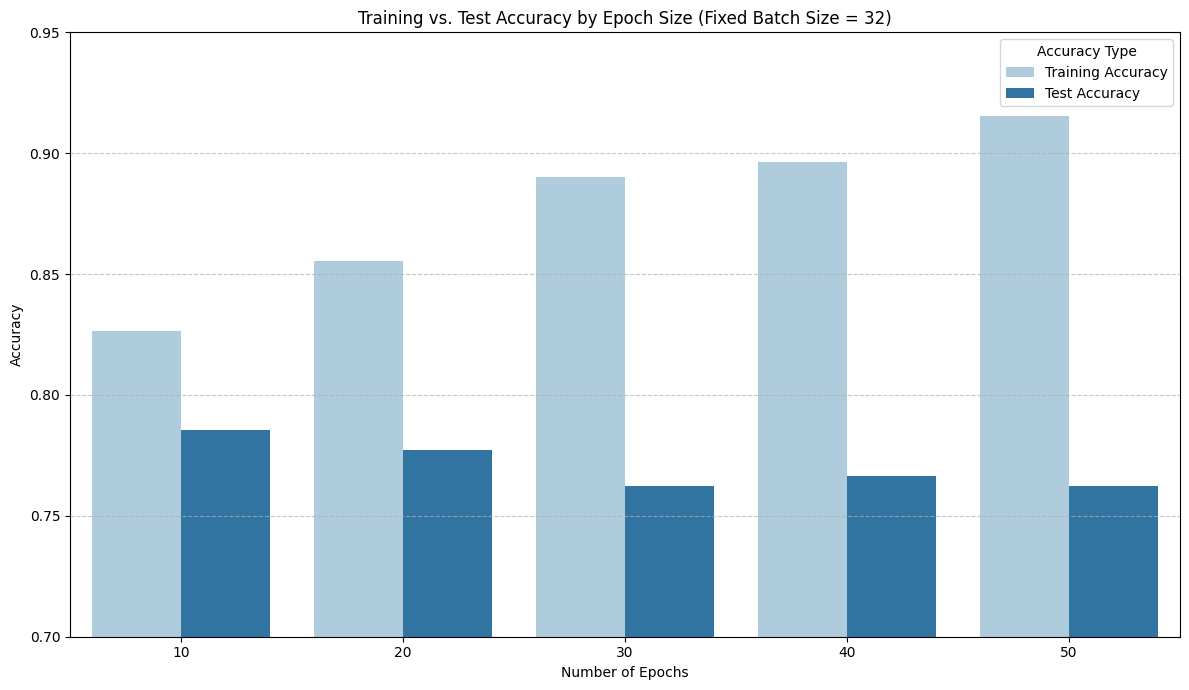

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Prepare data for plotting
accuracy_data = []
for epochs_val, metrics_data in epoch_histories.items():
    last_epoch_train_accuracy = metrics_data['history'].history['accuracy'][-1]
    test_accuracy = metrics_data['test_accuracy']
    accuracy_data.append({
        'Epochs': epochs_val,
        'Metric': 'Training Accuracy',
        'Value': last_epoch_train_accuracy
    })
    accuracy_data.append({
        'Epochs': epochs_val,
        'Metric': 'Test Accuracy',
        'Value': test_accuracy
    })

df_grouped_accuracy = pd.DataFrame(accuracy_data)

# Create the grouped bar chart
plt.figure(figsize=(12, 7))
sns.barplot(x='Epochs', y='Value', hue='Metric', data=df_grouped_accuracy, palette='Paired')
plt.title('Training vs. Test Accuracy by Epoch Size (Fixed Batch Size = 32)')
plt.xlabel('Number of Epochs')
plt.ylabel('Accuracy')
plt.ylim(0.7, 0.95) # Adjust y-limit for better visualization of differences
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Accuracy Type')
plt.tight_layout()
plt.show()

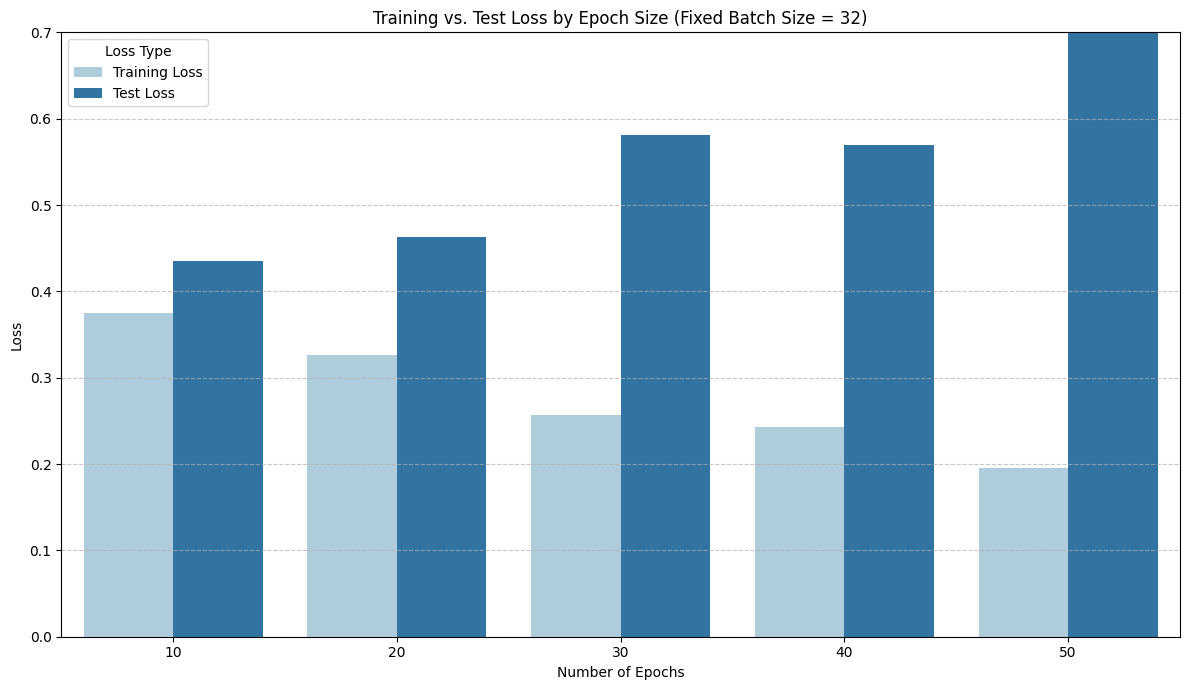

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Prepare data for plotting
loss_data = []
for epochs_val, metrics_data in epoch_histories.items():
    last_epoch_train_loss = metrics_data['history'].history['loss'][-1]
    test_loss = metrics_data['test_loss']
    loss_data.append({
        'Epochs': epochs_val,
        'Metric': 'Training Loss',
        'Value': last_epoch_train_loss
    })
    loss_data.append({
        'Epochs': epochs_val,
        'Metric': 'Test Loss',
        'Value': test_loss
    })

df_grouped_loss = pd.DataFrame(loss_data)

# Create the grouped bar chart
plt.figure(figsize=(12, 7))
sns.barplot(x='Epochs', y='Value', hue='Metric', data=df_grouped_loss, palette='Paired')
plt.title('Training vs. Test Loss by Epoch Size (Fixed Batch Size = 32)')
plt.xlabel('Number of Epochs')
plt.ylabel('Loss')
plt.ylim(0, 0.7) # Adjust y-limit for better visualization of differences
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Loss Type')
plt.tight_layout()
plt.show()

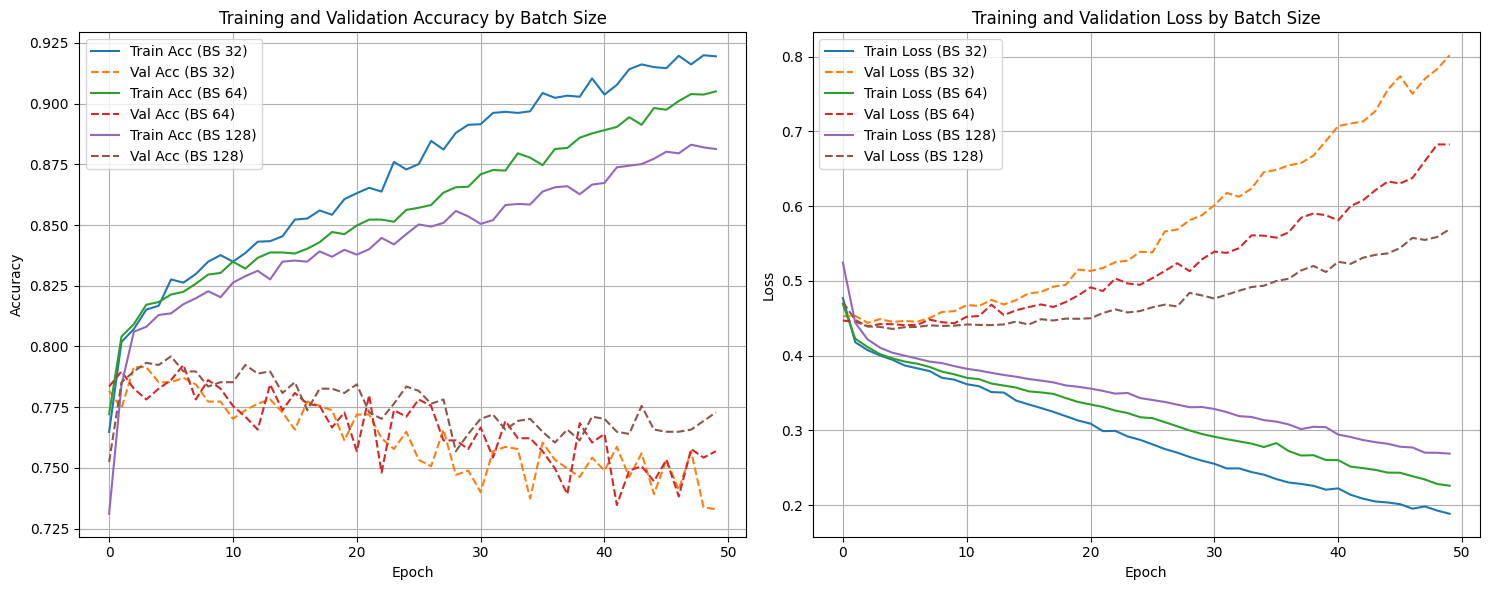

In [ ]:
import matplotlib.pyplot as plt

# Create a figure for accuracy
plt.figure(figsize=(15, 6))

# Plot Training Accuracy for all batch sizes
plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
for bs, hist in histories.items():
    plt.plot(hist['history'].history['accuracy'], label=f'Train Acc (BS {bs})')
    plt.plot(hist['history'].history['val_accuracy'], label=f'Val Acc (BS {bs})', linestyle='--')
plt.title('Training and Validation Accuracy by Batch Size')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Plot Training Loss for all batch sizes
plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
for bs, hist in histories.items():
    plt.plot(hist['history'].history['loss'], label=f'Train Loss (BS {bs})')
    plt.plot(hist['history'].history['val_loss'], label=f'Val Loss (BS {bs})', linestyle='--')
plt.title('Training and Validation Loss by Batch Size')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## 12.1 Training and Test Accuracy/Loss Plot by Epoch Size

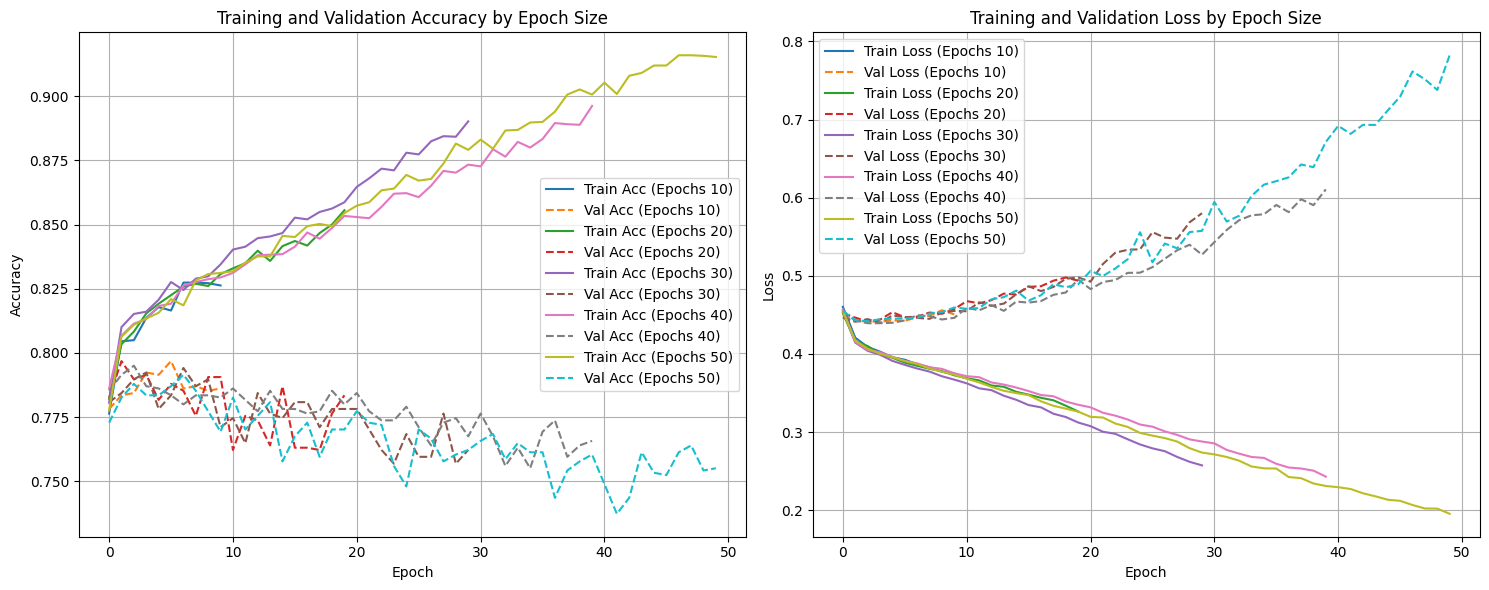

In [ ]:
import matplotlib.pyplot as plt

# Create a figure for accuracy and loss over different epoch sizes
plt.figure(figsize=(15, 6))

# Plot Training and Validation Accuracy for all epoch sizes
plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
for epochs_val, metrics_data in epoch_histories.items():
    train_history = metrics_data['history']
    plt.plot(train_history.history['accuracy'], label=f'Train Acc (Epochs {epochs_val})')
    plt.plot(train_history.history['val_accuracy'], label=f'Val Acc (Epochs {epochs_val})', linestyle='--')
plt.title('Training and Validation Accuracy by Epoch Size')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Plot Training and Validation Loss for all epoch sizes
plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
for epochs_val, metrics_data in epoch_histories.items():
    train_history = metrics_data['history']
    plt.plot(train_history.history['loss'], label=f'Train Loss (Epochs {epochs_val})')
    plt.plot(train_history.history['val_loss'], label=f'Val Loss (Epochs {epochs_val})', linestyle='--')
plt.title('Training and Validation Loss by Epoch Size')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## 11. TRAINING ACCURACY AND LOSS GRAPH

We visualize the training and validation accuracy and loss over epochs. This helps us understand if the model is learning effectively and if there are signs of overfitting.

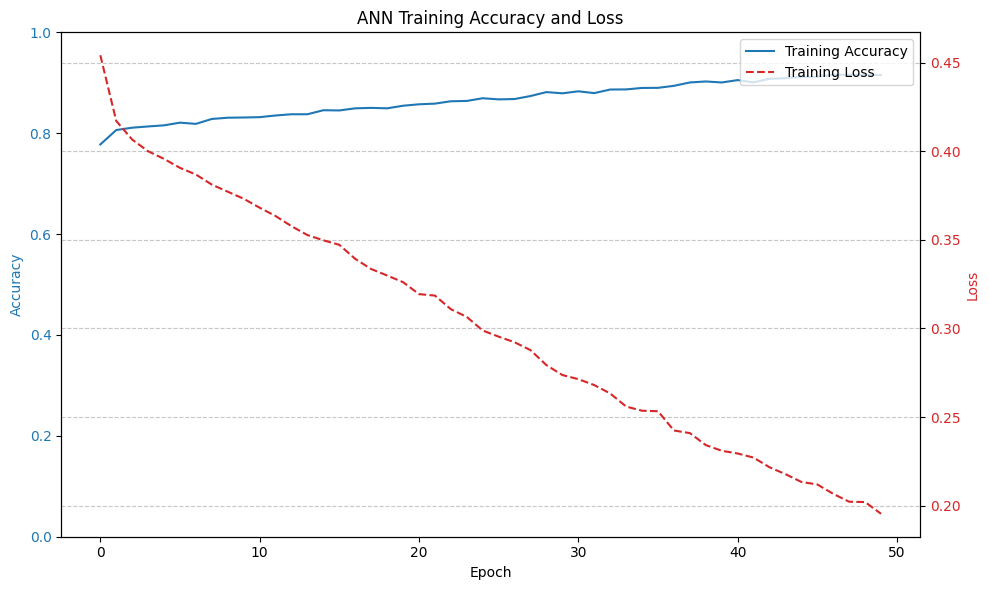

In [ ]:
# Create a figure with two y-axes for accuracy and loss on the same plot
fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot Training Accuracy
color = 'tab:blue'
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy', color=color)
ax1.plot(history.history['accuracy'], label='Training Accuracy', color=color, linestyle='-')
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_ylim([0, 1]) # Accuracy ranges from 0 to 1

# Create a second y-axis for Loss
ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Loss', color=color)
ax2.plot(history.history['loss'], label='Training Loss', color=color, linestyle='--')
ax2.tick_params(axis='y', labelcolor=color)

# Add title and legend
plt.title('ANN Training Accuracy and Loss')
fig.tight_layout()  # Adjust layout to prevent overlapping

# Manually create legends to show both lines on one plot
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(handles1 + handles2, labels1 + labels2, loc='upper right')

plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

## 12. TEST THE MODEL

After training, we evaluate the model's performance on the unseen test dataset to get a realistic measure of its generalization capability.

In [ ]:
# Evaluate the model on the test data
# `verbose=0` suppresses the progress bar during evaluation.
test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test,
    verbose=0
)

# Print the testing accuracy and loss
print(f"Testing Accuracy: {test_accuracy * 100:.2f}%")
print(f"Testing Loss: {test_loss:.4f}")

Testing Accuracy: 73.03%
Testing Loss: 1.7384


## 13. TESTING ACCURACY AND LOSS GRAPH

We'll visualize the final testing accuracy and loss to clearly show the model's performance on unseen data.

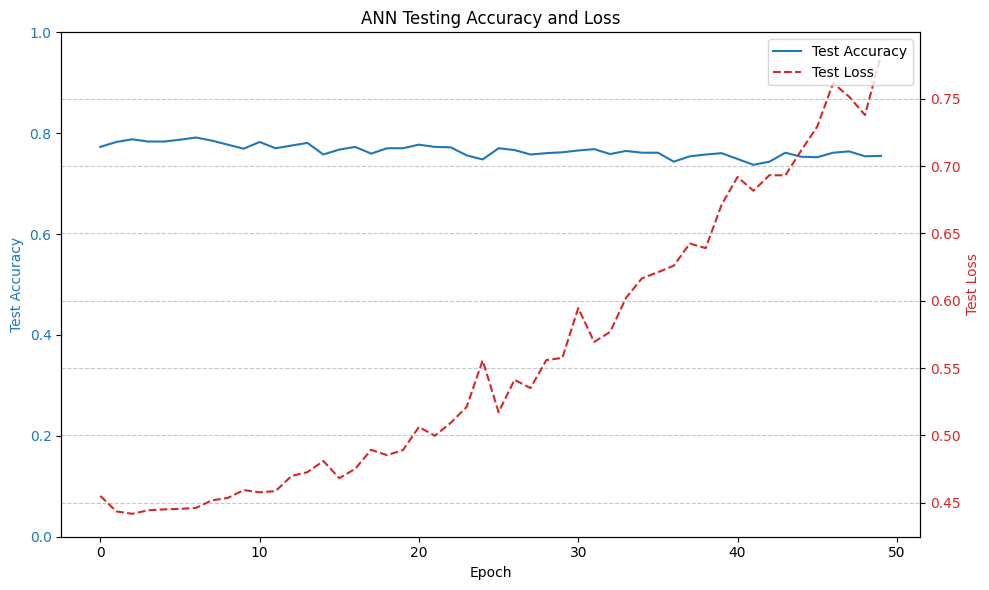

In [ ]:
# Create a figure with two y-axes for Test Accuracy and Test Loss
fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot Test Accuracy
color = 'tab:blue'
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Test Accuracy', color=color)
ax1.plot(history.history['val_accuracy'],
         label='Test Accuracy',
         color=color,
         linestyle='-')
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_ylim([0, 1])  # Accuracy ranges from 0 to 1

# Create a second y-axis for Test Loss
ax2 = ax1.twinx()

color = 'tab:red'
ax2.set_ylabel('Test Loss', color=color)
ax2.plot(history.history['val_loss'],
         label='Test Loss',
         color=color,
         linestyle='--')
ax2.tick_params(axis='y', labelcolor=color)

# Add title
plt.title('ANN Testing Accuracy and Loss')

# Adjust layout
fig.tight_layout()

# Combine both legends
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()

ax2.legend(handles1 + handles2,
           labels1 + labels2,
           loc='upper right')

# Add grid
plt.grid(True, linestyle='--', alpha=0.7)

# Show graph
plt.show()

## 14. CHURN PREDICTION

Now, let's use our trained model to make predictions on the test dataset. We'll get probability scores and then convert them into binary churn/no-churn labels.

In [ ]:
# Predict churn probabilities on the scaled test data
# model.predict returns probabilities for each class (churn or no churn).
y_probability = model.predict(X_test)

# Convert probabilities to binary predictions (0 or 1)
# If probability >= 0.5, predict 1 (Churn), otherwise 0 (No Churn).
y_prediction = (
    y_probability >= 0.5
).astype(int)

# Convert numerical predictions (0 or 1) into readable labels (CHURN / NO CHURN)
prediction_labels = np.where(
    y_prediction == 1,
    "CHURN",
    "NO CHURN"
)

print("Predictions generated successfully!")

45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
Predictions generated successfully!


## 15. DISPLAY PREDICTIONS

We'll create a DataFrame to compare the actual churn status with our model's predicted churn probability and the final churn prediction for the test set. This provides a clear overview of the model's output.

In [ ]:
# ==========================================
# ALL ORIGINAL ROWS + CUSTOMER ID
# ==========================================

X_all = X
X_all_scaled = scaler.transform(X_all)

# ANN prediction
y_pred_prob = model.predict(X_all_scaled, verbose=0)
y_pred = (y_pred_prob >= 0.5).astype(int).ravel()

# Actual values
y_actual = np.asarray(y).astype(int).ravel()

# Create result
results = pd.DataFrame({
    "No": range(1, len(y_actual) + 1),
    "Actual": np.where(y_actual == 1, "CHURN", "NO CHURN"),
    "Predicted": np.where(y_pred == 1, "CHURN", "NO CHURN")
})

# Add Customer ID if available
if "customerID" in df.columns:
    results.insert(1, "Customer ID", df["customerID"].values)

# Display all rows
results

,No,Actual,Predicted
0,1,NO CHURN,NO CHURN
1,2,NO CHURN,NO CHURN
2,3,CHURN,CHURN
3,4,NO CHURN,NO CHURN
4,5,CHURN,CHURN
...,...,...,...
7038,7039,NO CHURN,NO CHURN
7039,7040,NO CHURN,NO CHURN
7040,7041,NO CHURN,NO CHURN
7041,7042,CHURN,NO CHURN


In [ ]:
results.to_excel("ANN_Actual_vs_Predicted_All_Rows.xlsx", index=False)

print("Saved successfully!")

Saved successfully!


In [ ]:
import pandas as pd
from google.colab import files

# Load your original Telco dataset
df = pd.read_excel("Telco_Customer_Churn_Excel.xlsx")

# Create separate output file
results = df.copy()

# Add original row number
results.insert(0, "Original Row No", range(1, len(results) + 1))

# Convert Churn into readable Actual Churn
results["Actual Churn"] = results["Churn"].map({
    "Yes": "CHURN",
    "No": "NO CHURN"
})

# Save as separate Excel file
output_file = "Telco_Actual_Churn_All_Rows.xlsx"
results.to_excel(output_file, index=False)

# Download automatically
files.download(output_file)

print("File created successfully!")
print("Total rows:", len(results))

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

File created successfully!
Total rows: 7043


In [ ]:
# Create a dictionary to store the columns of the original DataFrame
original_cols = X.columns.tolist()


def predict_single_customer_churn(customer_data, model, scaler, original_columns):

    # Convert customer dictionary into DataFrame
    input_df = pd.DataFrame([customer_data])

    # Apply one-hot encoding
    input_df = pd.get_dummies(input_df, drop_first=True)

    # Make sure columns are exactly the same as training data
    input_df = input_df.reindex(columns=original_columns, fill_value=0)

    # Scale the input data
    scaled_input = scaler.transform(input_df)

    # Predict churn probability
    churn_probability = model.predict(scaled_input, verbose=0)[0][0]

    # Final prediction
    prediction = "CHURN 🚨" if churn_probability >= 0.5 else "NO CHURN ✅"

    print("=" * 40)
    print("      CUSTOMER CHURN PREDICTION")
    print("=" * 40)
    print(f"Churn Probability : {churn_probability * 100:.2f}%")
    print(f"Prediction        : {prediction}")
    print("=" * 40)


# =========================================================
# CUSTOMER 1
# =========================================================

hypothetical_customer_1 = {
    'SeniorCitizen': 0,
    'tenure': 12,
    'MonthlyCharges': 70.0,
    'TotalCharges': 840.0,

    'gender_1': True,
    'Partner_Yes': True,
    'Dependents_Yes': False,
    'PhoneService_Yes': True,

    'MultipleLines_No phone service': False,
    'MultipleLines_Yes': True,

    'InternetService_Fiber optic': True,
    'InternetService_No': False,

    'OnlineSecurity_No internet service': False,
    'OnlineSecurity_Yes': False,

    'OnlineBackup_No internet service': False,
    'OnlineBackup_Yes': True,

    'DeviceProtection_No internet service': False,
    'DeviceProtection_Yes': False,

    'TechSupport_No internet service': False,
    'TechSupport_Yes': False,

    'StreamingTV_No internet service': False,
    'StreamingTV_Yes': True,

    'StreamingMovies_No internet service': False,
    'StreamingMovies_Yes': True,

    'Contract_One year': False,
    'Contract_Two year': False,

    'PaperlessBilling_Yes': True,

    'PaymentMethod_Credit card (automatic)': False,
    'PaymentMethod_Electronic check': True,
    'PaymentMethod_Mailed check': False
}


# =========================================================
# CUSTOMER 2
# =========================================================

hypothetical_customer_2 = {
    'SeniorCitizen': 1,
    'tenure': 2,
    'MonthlyCharges': 80.0,
    'TotalCharges': 160.0,

    'gender_1': False,
    'Partner_Yes': False,
    'Dependents_Yes': False,
    'PhoneService_Yes': True,

    'MultipleLines_No phone service': False,
    'MultipleLines_Yes': False,

    'InternetService_Fiber optic': True,
    'InternetService_No': False,

    'OnlineSecurity_No internet service': False,
    'OnlineSecurity_Yes': False,

    'OnlineBackup_No internet service': False,
    'OnlineBackup_Yes': False,

    'DeviceProtection_No internet service': False,
    'DeviceProtection_Yes': False,

    'TechSupport_No internet service': False,
    'TechSupport_Yes': False,

    'StreamingTV_No internet service': False,
    'StreamingTV_Yes': False,

    'StreamingMovies_No internet service': False,
    'StreamingMovies_Yes': False,

    'Contract_One year': False,
    'Contract_Two year': False,

    'PaperlessBilling_Yes': True,

    'PaymentMethod_Credit card (automatic)': False,
    'PaymentMethod_Electronic check': True,
    'PaymentMethod_Mailed check': False
}


# =========================================================
# PREDICTIONS
# =========================================================

print("\n--- Prediction for Customer 1 ---")
predict_single_customer_churn(
    hypothetical_customer_1,
    model,
    scaler,
    original_cols
)

print("\n--- Prediction for Customer 2 ---")
predict_single_customer_churn(
    hypothetical_customer_2,
    model,
    scaler,
    original_cols
)


--- Prediction for Customer 1 ---
      CUSTOMER CHURN PREDICTION
Churn Probability : 98.63%
Prediction        : CHURN 🚨

--- Prediction for Customer 2 ---
      CUSTOMER CHURN PREDICTION
Churn Probability : 75.90%
Prediction        : CHURN 🚨


## 17. MODEL EVALUATION

Beyond just accuracy, we use a classification report and confusion matrix to get a more detailed understanding of our model's performance, especially regarding False Positives and False Negatives.

In [ ]:
# Calculate and print the overall accuracy on the test set
accuracy = accuracy_score(
    y_test,
    y_prediction
)
print(f"Accuracy: {accuracy * 100:.2f}%")

# Print the classification report, which includes precision, recall, and f1-score for each class
print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_prediction,
        target_names=[
            "No Churn", # Label for class 0
            "Churn"     # Label for class 1
        ]
    )
)

# Calculate the confusion matrix
cm = confusion_matrix(
    y_test,
    y_prediction
)

# Print the confusion matrix
print("\nConfusion Matrix (Raw):")
print(cm)

Accuracy: 73.03%

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.82      0.82      0.82      1035
       Churn       0.49      0.49      0.49       374

    accuracy                           0.73      1409
   macro avg       0.65      0.65      0.65      1409
weighted avg       0.73      0.73      0.73      1409


Confusion Matrix (Raw):
[[847 188]
 [192 182]]


## 18. CONFUSION MATRIX

Visualizing the confusion matrix helps us understand where our model is making mistakes. It shows the counts of true positives, true negatives, false positives, and false negatives.

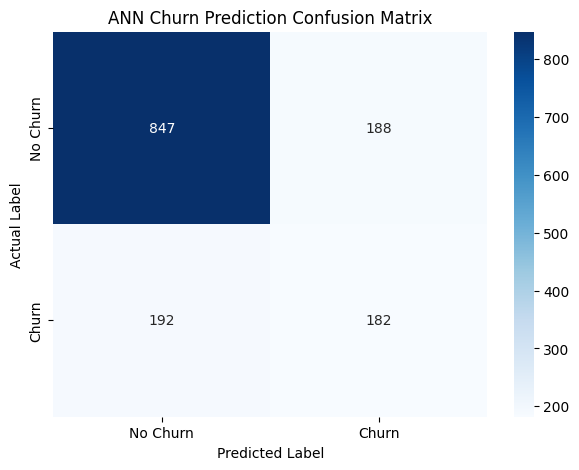

In [ ]:
# Visualize the confusion matrix using a heatmap for better readability
plt.figure(figsize=(7, 5))
sns.heatmap(
    cm,
    annot=True, # Annotate cells with data values
    fmt='d',    # Format annotations as integers
    cmap='Blues', # Color map for the heatmap
    xticklabels=["No Churn", "Churn"], # Labels for predicted classes
    yticklabels=["No Churn", "Churn"]  # Labels for actual classes
)
plt.title('ANN Churn Prediction Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

## FINAL RESULT

Our **Telco Customer Churn Prediction using ANN** model successfully predicts whether a customer is likely to **Churn or Not Churn** based on their customer details.

We performed data preprocessing, categorical encoding, feature scaling, and trained an Artificial Neural Network with **64, 32, and 16 neurons** in the hidden layers. **ReLU** activation was used in the hidden layers and **Sigmoid** activation was used in the output layer for binary classification.

We used **Adam optimizer** and **Binary Cross Entropy loss function** for training. We also compared different batch sizes — **32, 64, and 128** — as part of hyperparameter tuning. Among the tested values, **batch size 128 achieved the best test accuracy of 77.00% with a test loss of 0.5525**.

The model can also predict the churn probability of an individual customer. For example, one sample customer received a **98.63% churn probability and was classified as CHURN**.

Therefore, this system can help telecom companies **identify customers who are at high risk of leaving and take early customer-retention actions**.
